In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import tensorflow as tf
# Set parameters
image_size = (240, 240)
batch_size = 64
# Load the dataset from the folder
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\imp\Project\CoLeaf DATASET - Updated",
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical'  # or 'categorical' for multi-class classification
)
# Visualize the dataset
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape, labels_batch.shape)
className = dataset.class_names
print("Class Name: ",className)


Found 767 files belonging to 8 classes.
(64, 240, 240, 3) (64, 8)
Class Name:  ['boron-B', 'calcium-Ca', 'healthy', 'iron-Fe', 'manganese-Mn', 'nitrogen-N', 'phosphorus-P', 'potasium-K']


In [4]:

test_split = 0.2 #20 percentage for testing
dataset_size = len(dataset)  # This returns the number of batches
test_size = int(test_split * dataset_size)
train_size = dataset_size - test_size

# Split the dataset
train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)

for image_batch, labels_batch in train_dataset.take(1):
    print("Train batch shape:", image_batch.shape, labels_batch.shape)

for image_batch, labels_batch in test_dataset.take(1):
    print("Test batch shape:", image_batch.shape, labels_batch.shape)

Train batch shape: (64, 240, 240, 3) (64, 8)
Test batch shape: (64, 240, 240, 3) (64, 8)


In [5]:
import numpy as np
X_train, y_train =[], []
for image_batch, labels_batch in train_dataset:
    X_train.append(image_batch.numpy())
    y_train.append(labels_batch.numpy())


X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

X_test, y_test = [], []
for image_batch, labels_batch in test_dataset:
    X_test.append(image_batch.numpy())
    y_test.append(labels_batch.numpy())

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(640, 240, 240, 3) (640, 8)
(127, 240, 240, 3) (127, 8)


In [6]:
X_train, X_test = X_train / 255.0, X_test / 255.0  #Normalize the value

In [7]:
# def increaseContrast(images,contrast_factor):
#     images = tf.image.adjust_contrast(images,contrast_factor)
#     return images

### with concatination

In [8]:
from tensorflow.keras import layers, models
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class ContrastLayer(tf.keras.layers.Layer):
    def __init__(self, initial_contrast=4.5, **kwargs):
        super(ContrastLayer, self).__init__(**kwargs)
        self.initial_contrast = initial_contrast

    def call(self, inputs):
        return tf.image.adjust_contrast(inputs, self.initial_contrast)

    def get_config(self):
        config = super().get_config()
        config.update({"initial_contrast": self.initial_contrast})
        return config


In [9]:


##### from tensorflow.keras import layers, models
from tensorflow.keras.layers import concatenate

# X_train = increaseContrast(X_train, 5.5)
# X_test = increaseContrast(X_test, 5.5)


# Input layer
input_layer = layers.Input(shape=(240, 240, 3))
contrast_layer = ContrastLayer(initial_contrast=5)(input_layer) 

# First convolutional block (low-level features)
conv1 = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(contrast_layer)
pool1 = layers.MaxPooling2D((3, 3))(conv1)
# Add Dropout after the first pooling layer
dropout1 = layers.Dropout(0.03)(pool1)  # Experiment with dropout rate (0.25 is a common starting point)

# Second convolutional block (mid-level features)
conv2 = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(pool1)
pool2 = layers.MaxPooling2D((3, 3))(dropout1)
# Add Dropout after the second pooling layer
dropout2 = layers.Dropout(0.03)(pool2)

# Third convolutional block (high-level features)
conv3 = layers.Conv2D(128, (5, 5), activation='relu', padding='same')(dropout2)
pool3 = layers.MaxPooling2D((3, 3))(conv3)
# Add Dropout after the third pooling layer
dropout3 = layers.Dropout(0.03)(pool3)

# Apply MaxPooling and Global Average Pooling to extract low and high-level features
max_pool = layers.MaxPooling2D(pool_size=(1, 1))(dropout3)  # Low-level (detail) features
avg_pool = layers.GlobalAveragePooling2D()(dropout3)  # High-level (summary) features

# Flatten the max pooled features (as it has spatial dimensions)
max_pool_flatten = layers.Flatten()(max_pool)

# Concatenate the max-pooled and average-pooled features
fused_features = concatenate([max_pool_flatten, avg_pool])

# Fully connected layer with Dropout
fc1 = layers.Dense(64, activation='relu')(fused_features)
dropout4 = layers.Dropout(0.03)(fc1)  # Add Dropout after the fully connected layer

# Output layer (assuming 8 classes)
output_layer = layers.Dense(8, activation='softmax')(dropout4)

# Create the model
model = models.Model(inputs=input_layer, outputs=output_layer)

# Compile the model
from tensorflow.keras.optimizers import Adam

# Lower learning rate for fine-tuning
optimizer = Adam(learning_rate=0.001)  # Default is 0.001

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [10]:
# Train the model
history = model.fit(X_train, y_train, epochs=50,
                    validation_data=(X_test, y_test),batch_size=32)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 421ms/step - accuracy: 0.2606 - loss: 2.1347 - val_accuracy: 0.3307 - val_loss: 1.6925
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 464ms/step - accuracy: 0.4521 - loss: 1.5659 - val_accuracy: 0.4646 - val_loss: 1.4746
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.4810 - loss: 1.3077 - val_accuracy: 0.4961 - val_loss: 1.3281
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 414ms/step - accuracy: 0.5822 - loss: 1.1205 - val_accuracy: 0.6299 - val_loss: 1.0356
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 451ms/step - accuracy: 0.6452 - loss: 1.0128 - val_accuracy: 0.7008 - val_loss: 0.8535
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 482ms/step - accuracy: 0.7243 - loss: 0.7901 - val_accuracy: 0.7717 - val_loss: 0.7646
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 409ms/step - accuracy: 0.7559 - loss: 0.7009 - val_accuracy: 0.7638 - val_loss: 0.6852
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 469ms/step - accuracy: 0.7345 - loss: 0.6896 - val_accuracy: 

In [44]:
import pandas as pd

# Convert history to DataFrame
history_df = pd.DataFrame(history.history)

# Save to CSV file
history_df.to_csv(r"C:\imp\Project\results\novel\training_history.csv", index=False)


print("Training history saved successfully!")


Training history saved successfully!


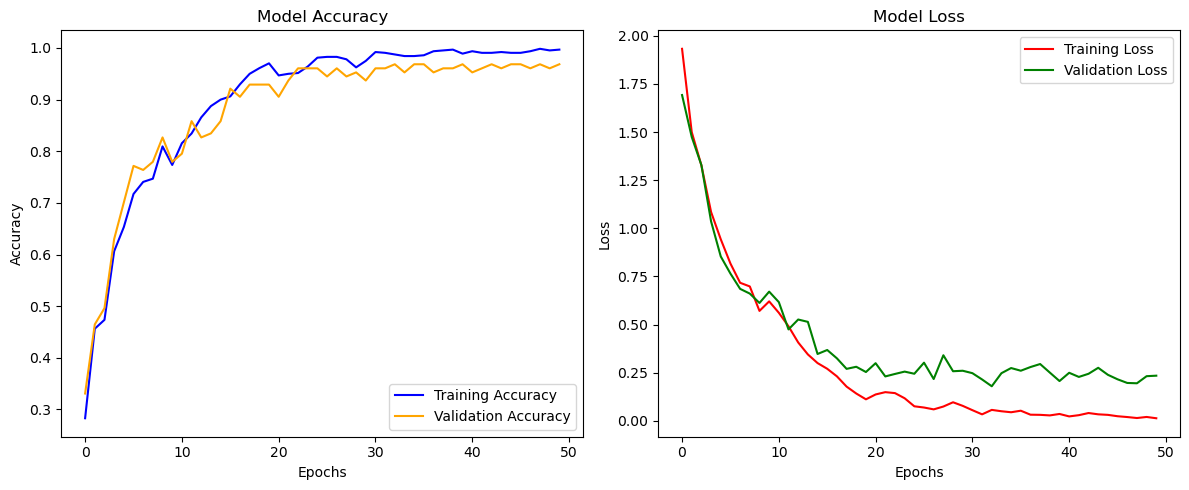

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
history_df = pd.read_csv("training_history.csv")

# Create a figure with two subplots (1 row, 2 columns)
plt.figure(figsize=(12, 5))

# 1️⃣ Plot Accuracy
plt.subplot(1, 2, 1)  # (rows, columns, index)
plt.plot(history_df["accuracy"], label="Training Accuracy", color='blue')
plt.plot(history_df["val_accuracy"], label="Validation Accuracy", color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

# 2️⃣ Plot Loss
plt.subplot(1, 2, 2)  # Second subplot
plt.plot(history_df["loss"], label="Training Loss", color='red')
plt.plot(history_df["val_loss"], label="Validation Loss", color='green')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

plt.savefig(r"C:\imp\Project\results\novel\acc_loss")
# Show the combined figure
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


### wihout concatination of maxpool and avarage pool

In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
img_path = r"C:/Users/snesh/Downloads/WhatsApp Image 2025-03-11 at 10.59.50_4e903c5d.jpg"
img = image.load_img(img_path, target_size=(240, 240))  # Resize to match model input
img_array = image.img_to_array(img)  # Convert to numpy array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize if required by your model


predictions = model.predict(img_array)
predicted_class = np.argmax(predictions)  # Get the class index with highest probability

print(f"Predicted Class: {predicted_class}")
print(className[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Class: 2
healthy


In [24]:
model.save("cnn_model.keras")  # Saves in HDF5 format


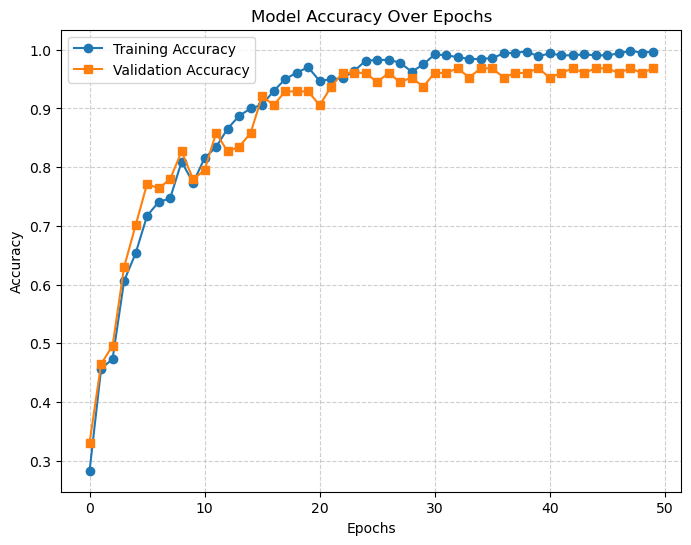

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Epochs')

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig(r"C:\imp\Project\results\novel\acc_only")
# Show plot
plt.show()
plt.savefig("33 cnn_noovel")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


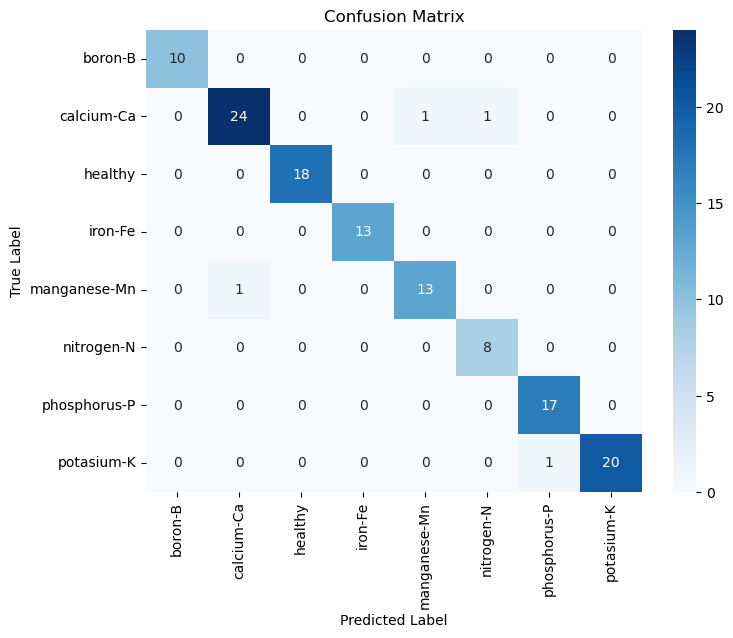

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define class names (Replace with your actual class names)


# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # True labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=className, yticklabels=className)

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.savefig(r"C:\imp\Project\results\novel\conf")

# Save and show plot
plt.savefig("confusion_matrix_33.png", dpi=300, bbox_inches='tight')  # Save as high-quality PNG
plt.show()


C:\Users\snesh\AppData\Local\Temp\ipykernel_18052\3034485412.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=className, y=class_accuracy, palette="viridis")


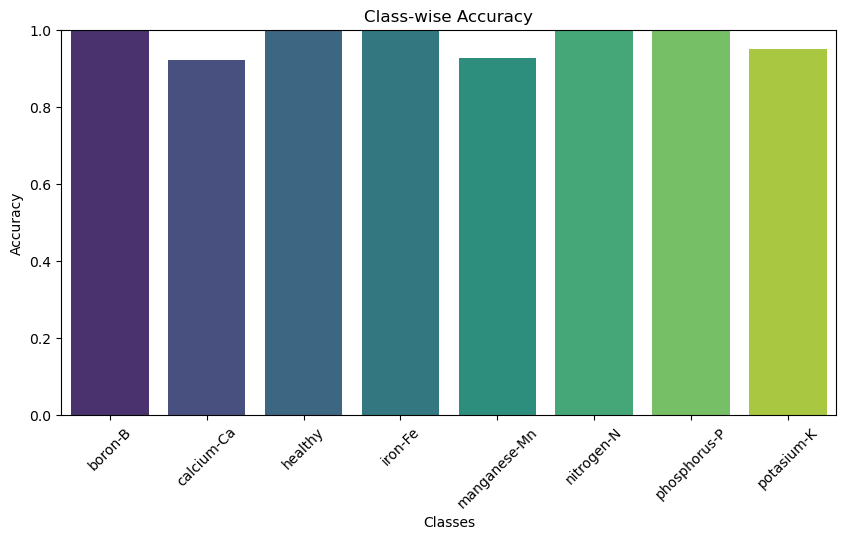

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Compute class-wise accuracy
num_classes = len(className)
class_accuracy = []
for i in range(num_classes):
    indices = np.where(y_true == i)
    class_acc = accuracy_score(y_true[indices], y_pred_classes[indices])
    class_accuracy.append(class_acc)

# Plot bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=className, y=class_accuracy, palette="viridis")

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Accuracy')
plt.title('Class-wise Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Accuracy range (0 to 1)

plt.savefig(r"C:\imp\Project\results\novel\bar_acc")
# Show plot
plt.savefig(" 33 cnn_novel")
plt.show()


In [28]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_true, y_pred_classes, target_names=className)

# Print the report
print(report)


              precision    recall  f1-score   support

     boron-B       1.00      1.00      1.00        10
  calcium-Ca       0.96      0.92      0.94        26
     healthy       1.00      1.00      1.00        18
     iron-Fe       1.00      1.00      1.00        13
manganese-Mn       0.93      0.93      0.93        14
  nitrogen-N       0.89      1.00      0.94         8
phosphorus-P       0.94      1.00      0.97        17
  potasium-K       1.00      0.95      0.98        21

    accuracy                           0.97       127
   macro avg       0.97      0.98      0.97       127
weighted avg       0.97      0.97      0.97       127



In [29]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# Function to get Grad-CAM heatmap
def get_gradcam_heatmap(model, img_array, class_index=None, layer_name='conv2d_8'):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = np.argmax(predictions[0])  # Get highest probability class
        loss = predictions[:, class_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Convert tensors to NumPy arrays
    conv_outputs = conv_outputs[0].numpy()
    pooled_grads = pooled_grads.numpy()

    # Multiply gradients with feature maps
    for i in range(conv_outputs.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    # Generate heatmap
    heatmap = np.mean(conv_outputs, axis=-1)  # Change tf.reduce_mean to np.mean
    heatmap = np.maximum(heatmap, 0)  # Apply ReLU

    # Normalize heatmap
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)  

    return heatmap

# Function to overlay Grad-CAM heatmap on image
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)  # Convert to uint8
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Ensure img is in uint8 format
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return superimposed_img


# Function to display original image and Grad-CAM side by side
def show_gradcam(model, img, layer_name='conv2d_8', class_index=None):
    img_array = np.expand_dims(img, axis=0)  # Add batch dimension
    heatmap = get_gradcam_heatmap(model, img_array, class_index, layer_name)

    gradcam_img = overlay_gradcam(img, heatmap)

    plt.figure(figsize=(10, 5))
    
    # Show original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    # Show Grad-CAM overlay
    plt.subplot(1, 2, 2)
    plt.imshow(gradcam_img)
    plt.title("Grad-CAM Visualization")
    plt.axis("off")

    plt.show()




In [31]:
import os

# Create directory if it doesn't exist
output_dir = r"C:\imp\Project\grad_cam"
os.makedirs(output_dir, exist_ok=True)

def save_gradcam(model, img, index, layer_name='conv2d_2', class_index=None):
    img_array = np.expand_dims(img, axis=0)  # Add batch dimension
    heatmap = get_gradcam_heatmap(model, img_array, class_index, layer_name)
    gradcam_img = overlay_gradcam(img, heatmap)

    # Convert to RGB if needed (assuming the image is in grayscale)
    if len(gradcam_img.shape) == 2:  
        gradcam_img = cv2.cvtColor(gradcam_img, cv2.COLOR_GRAY2RGB)

    # Save image
    filename = os.path.join(output_dir, f"gradcam_{index}.png")
    cv2.imwrite(filename, gradcam_img)
    print(f"Saved: {filename}")

# Process and save Grad-CAM images for first 10 samples
for i in range(10):
    sample_img = X_test[i]  # Replace with actual test image
    save_gradcam(model, sample_img, i)


Saved: C:\imp\Project\grad_cam\gradcam_0.png
Saved: C:\imp\Project\grad_cam\gradcam_1.png
Saved: C:\imp\Project\grad_cam\gradcam_2.png
Saved: C:\imp\Project\grad_cam\gradcam_3.png
Saved: C:\imp\Project\grad_cam\gradcam_4.png
Saved: C:\imp\Project\grad_cam\gradcam_5.png
Saved: C:\imp\Project\grad_cam\gradcam_6.png
Saved: C:\imp\Project\grad_cam\gradcam_7.png
Saved: C:\imp\Project\grad_cam\gradcam_8.png
Saved: C:\imp\Project\grad_cam\gradcam_9.png


In [37]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
output_dir = r"C:\imp\Project\grad_cam"
os.makedirs(output_dir, exist_ok=True)

def save_gradcam(model, img, index, layer_name='conv2d', class_index=None):
    img_array = np.expand_dims(img, axis=0)  # Add batch dimension
    heatmap = get_gradcam_heatmap(model, img_array, class_index, layer_name)
    gradcam_img = overlay_gradcam(img, heatmap)

    # Convert original image to correct format
    original_img = np.uint8(255 * img)  # Scale to 0-255 and convert to uint8
    original_img = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for OpenCV

    # Resize to ensure both images have the same size
    gradcam_img = cv2.resize(gradcam_img, (original_img.shape[1], original_img.shape[0]))

    # Concatenate images side by side
    combined_img = np.hstack((original_img, gradcam_img))

    # Save the combined image
    filename = os.path.join(output_dir, f"gradcam_{index}.png")
    cv2.imwrite(filename, combined_img)
    print(f"Saved: {filename}")

# Process and save Grad-CAM images for the first 10 samples
for i in range(50):
    sample_img = X_test[i]  # Replace with actual test image
    save_gradcam(model, sample_img, i)


Saved: C:\imp\Project\grad_cam\gradcam_0.png
Saved: C:\imp\Project\grad_cam\gradcam_1.png
Saved: C:\imp\Project\grad_cam\gradcam_2.png
Saved: C:\imp\Project\grad_cam\gradcam_3.png
Saved: C:\imp\Project\grad_cam\gradcam_4.png
Saved: C:\imp\Project\grad_cam\gradcam_5.png
Saved: C:\imp\Project\grad_cam\gradcam_6.png
Saved: C:\imp\Project\grad_cam\gradcam_7.png
Saved: C:\imp\Project\grad_cam\gradcam_8.png
Saved: C:\imp\Project\grad_cam\gradcam_9.png
Saved: C:\imp\Project\grad_cam\gradcam_10.png
Saved: C:\imp\Project\grad_cam\gradcam_11.png
Saved: C:\imp\Project\grad_cam\gradcam_12.png
Saved: C:\imp\Project\grad_cam\gradcam_13.png
Saved: C:\imp\Project\grad_cam\gradcam_14.png
Saved: C:\imp\Project\grad_cam\gradcam_15.png
Saved: C:\imp\Project\grad_cam\gradcam_16.png
Saved: C:\imp\Project\grad_cam\gradcam_17.png
Saved: C:\imp\Project\grad_cam\gradcam_18.png
Saved: C:\imp\Project\grad_cam\gradcam_19.png
Saved: C:\imp\Project\grad_cam\gradcam_20.png
Saved: C:\imp\Project\grad_cam\gradcam_21.pn

In [8]:
# from tensorflow.keras import layers, models

# # Input layer
# input_layer = layers.Input(shape=(240, 240, 3))
# contrast_layer = ContrastLayer(initial_contrast=4.5)(input_layer)

# # Convolutional layers
# conv1 = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(contrast_layer)
# pool1 = layers.MaxPooling2D((3, 3))(conv1)
# dropout1 = layers.Dropout(0.03)(pool1)

# conv2 = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(pool1)
# pool2 = layers.MaxPooling2D((3, 3))(dropout1)
# dropout2 = layers.Dropout(0.03)(pool2)

# conv3 = layers.Conv2D(128, (5, 5), activation='relu', padding='same')(dropout2)
# pool3 = layers.MaxPooling2D((3, 3))(conv3)
# dropout3 = layers.Dropout(0.03)(pool3)

# # Remove MaxPooling(1,1) and Flatten, use only GlobalAveragePooling
# avg_pool = layers.GlobalAveragePooling2D()(conv3)

# # Fully connected layer
# fc1 = layers.Dense(64, activation='relu')(avg_pool)
# dropout4 = layers.Dropout(0.03)(fc1)

# # Output layer
# output_layer = layers.Dense(8, activation='softmax')(dropout4)

# # Create the model
# model = models.Model(inputs=input_layer, outputs=output_layer)

# # Compile the model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Train the model
# history = model.fit(X_train, y_train, epochs=25, validation_data=(X_test, y_test), batch_size=32)



Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 463ms/step - accuracy: 0.1991 - loss: 2.0608 - val_accuracy: 0.2835 - val_loss: 1.9855
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 447ms/step - accuracy: 0.3416 - loss: 1.9015 - val_accuracy: 0.3071 - val_loss: 1.7862
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.3374 - loss: 1.6966 - val_accuracy: 0.3150 - val_loss: 1.6694
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 445ms/step - accuracy: 0.4256 - loss: 1.5321 - val_accuracy: 0.4016 - val_loss: 1.5483
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 453ms/step - accuracy: 0.5343 - loss: 1.3267 - val_accuracy: 0.4803 - val_loss: 1.4053
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 453ms/step - accuracy: 0.5569 - loss: 1.2705 - val_accuracy: 0.5354 - val_loss: 1.3314
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 455ms/step - accuracy: 0.5709 - loss: 1.1736 - val_accuracy: 0.4961 - val_loss: 1.2566
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.5852 - loss: 1.1942 - val_accuracy: 